In [1]:
import numpy as np
import pandas as pd
# from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm
from scipy.optimize import curve_fit

In [2]:
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py
death_wk_idx_ls = [30,34,38,43,47,51,56,60,64,65]
from scipy.signal import savgol_filter
def moving_average(data, window_size):
    """ Compute moving average """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
def exponential_moving_average(data, alpha):
    """ Compute exponential moving average """
    ema = []
    for point in data:
        if not ema:
            ema.append(point)
        else:
            ema.append(alpha * point + (1 - alpha) * ema[-1])
    return np.array(ema)

In [3]:
M_death_06_wk = np.loadtxt('deaths_06_phase2_v3.csv', delimiter=',')
# M_death_06_cum = np.cumsum(M_death_06_wk, axis=0)
inf_rates_06 = np.loadtxt('serology_rates_06.csv')

In [4]:
death_acc_wk = M_death_06_wk.cumsum(axis=0)
## need to include the idx week

In [5]:
death_m = np.zeros((10,5))
for m_i in range(10):
    until_wk_idx = death_wk_idx_ls[m_i]
    death_m[m_i,:] = death_acc_wk[until_wk_idx,:]

In [6]:
IFR_real_shape_06 = np.zeros((10,5)) ## month 3-7, 7-8, 9 ,10, 11, 12, 1, 2, 3, 4
month_inf_06 = global_N_06[:, np.newaxis] * inf_rates_06
### mean value of IFR
for i in range(10):
    IFR_real_shape_06[i,:] = death_m[i,:]/month_inf_06[:,i] #start with month 7

In [7]:
my_ifr_ts = np.zeros((28*14,5))
my_ifr_ts[:28*5] = IFR_real_shape_06[0]
for m_idx in range(5,14):
    my_ifr_ts[28*m_idx:28*(m_idx+1)] = IFR_real_shape_06[m_idx-4]

0 asian
1 white
2 black
3 latino
4 other


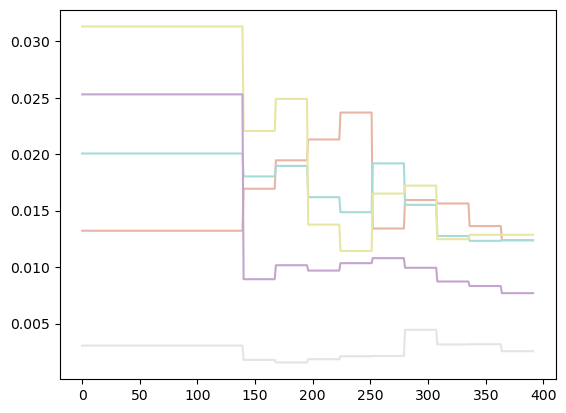

In [8]:
for r_idx in range(5):
    r = race_list_06[r_idx]
    plt.plot(my_ifr_ts[:,r_idx],label=r,c=custom_colors[r])
    print(r_idx, r)

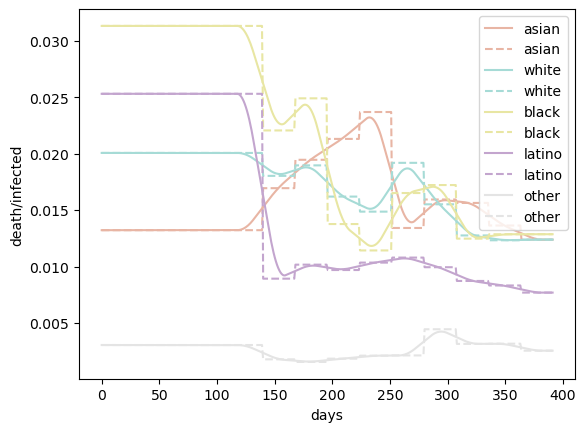

In [10]:
temp_v3 = np.zeros_like(my_ifr_ts) 
for r_idx in range(5):
    r = race_list_06[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(my_ifr_ts[:,r_idx], window_length=14, polyorder=1)
    # the original is 70
    temp2 = moving_average(temp,28)
    temp3 = np.zeros(my_ifr_ts.shape[0])
    temp3[13:-14] = temp2
    temp3[:14] = temp[:14]
    temp3[-14:] = my_ifr_ts[-14:,r_idx]
    temp_v3[:,r_idx] = temp3
    # temp = exponential_moving_average(my_ifr_ts[:,r_idx],0.5)
    # plt.plot(temp,label=r,c=custom_colors[r])
    plt.plot(temp3,label=r,c=custom_colors[r])
    # plt.plot(temp2,label=r,c=custom_colors[r])
    plt.plot(my_ifr_ts[:,r_idx],'--',label=r,c=custom_colors[r])
    plt.ylabel('death/infected')
    plt.xlabel('days')
plt.legend()

In [11]:
# np.savetxt('my_ifr_ts-v6_06.csv',temp_v3)

## location 37

In [14]:
M_death_37_wk = np.loadtxt('deaths_37_phase2_v3.csv', delimiter=',')
inf_rates_37 = np.loadtxt('serology_rates_37.csv')
n_r_37 = len(race_list_37)

In [15]:
death_acc_wk = M_death_37_wk.cumsum(axis=0)

In [16]:
death_m = np.zeros((10,n_r_37))
for m_i in range(10):
    until_wk_idx = death_wk_idx_ls[m_i]
    death_m[m_i,:] = death_acc_wk[until_wk_idx,:]

In [7]:
IFR_real_shape_37 = np.zeros((10,n_r_37)) ## month 3-7, 7-8, 9 ,10, 11, 12, 1, 2, 3, 4
month_inf_37 = global_N_37[:, np.newaxis] * inf_rates_37
### mean value of IFR
for i in range(10):
    IFR_real_shape_37[i,:] = death_m[i,:]/month_inf_37[:,i] #start with month 7

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_48839/1766145003.py:5: RuntimeWarning: divide by zero encountered in divide
  IFR_real_shape_37[i,:] = death_m[i,:]/month_inf_37[:,i] #start with month 7


In [8]:
IFR_real_shape_37[0,0] = 0

In [9]:
my_ifr_ts = np.zeros((28*14,n_r_37))
my_ifr_ts[:28*5] = IFR_real_shape_37[0]
for m_idx in range(5,14):
    my_ifr_ts[28*m_idx:28*(m_idx+1)] = IFR_real_shape_37[m_idx-4]

0 asian
1 white
2 black
3 other


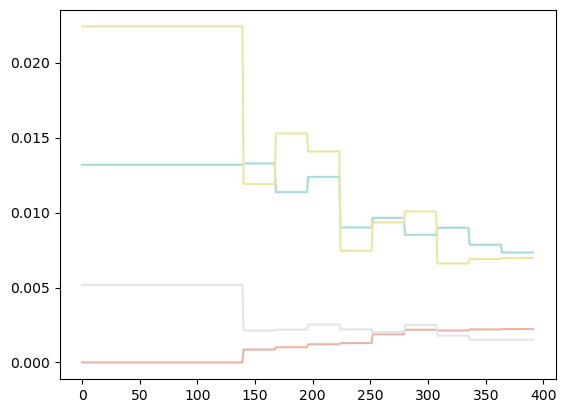

In [10]:
for r_idx in range(n_r_37):
    r = race_list_37[r_idx]
    plt.plot(my_ifr_ts[:,r_idx],label=r,c=custom_colors[r])
    print(r_idx, r)

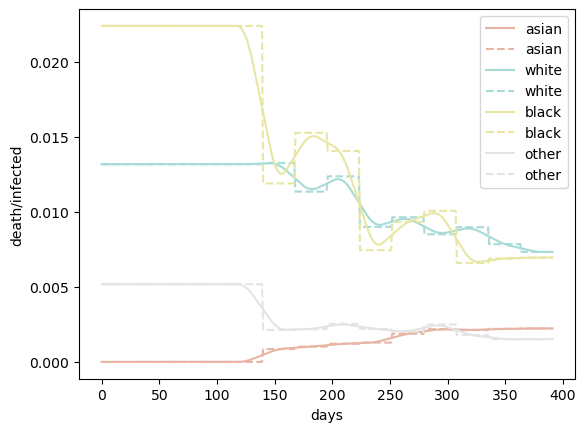

In [13]:
temp_v3 = np.zeros_like(my_ifr_ts) 
for r_idx in range(n_r_37):
    r = race_list_37[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(my_ifr_ts[:,r_idx], window_length=14, polyorder=1)
    # the original is 70
    temp2 = moving_average(temp,28)
    temp3 = np.zeros(my_ifr_ts.shape[0])
    temp3[13:-14] = temp2
    temp3[:14] = temp[:14]
    temp3[-14:] = my_ifr_ts[-14:,r_idx]
    temp_v3[:,r_idx] = temp3
    # temp = exponential_moving_average(my_ifr_ts[:,r_idx],0.5)
    # plt.plot(temp,label=r,c=custom_colors[r])
    plt.plot(temp3,label=r,c=custom_colors[r])
    # plt.plot(temp2,label=r,c=custom_colors[r])
    plt.plot(my_ifr_ts[:,r_idx],'--',label=r,c=custom_colors[r])
    plt.ylabel('death/infected')
    plt.xlabel('days')
plt.legend()

In [14]:
# np.savetxt('my_ifr_ts-v6_37.csv',temp_v3)